In [37]:
cd ..

c:\Users\Lenovo\Desktop\FYP\Tourist-Attraction-Recommendation-System


c:\Users\Lenovo\Desktop\FYP\Tourist-Attraction-Recommendation-System\venv\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [38]:
import pandas as pd
import numpy as np
import torch
from transformers import DistilBertModel, DistilBertTokenizer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


In [39]:
model = "distilbert-base-uncased"
# Load the tokenizer
tokenizer = DistilBertTokenizer.from_pretrained(model)
# Load the model
model = DistilBertModel.from_pretrained(model)

In [40]:
model

DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSdpaAttention(
          (dropout): Dropout(p=0.1, inplace=False)
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): L

In [42]:
attraction_df = pd.read_csv("./Data/FinalDataset/attractions_with_existing_description.csv")
ratings_df = pd.read_csv("./Data/FinalDataset/ratings.csv")
ratings_df.head()


,user_id,place_id,rating
0,1,NaN,3
1,2,NaN,1
2,3,NaN,5
3,4,NaN,4
4,5,NaN,5


In [43]:
# Rename the 'id' column to 'place_id'
attraction_df.rename(columns={'id': 'place_id'}, inplace=True)
attraction_df.head()

,place_id,name,address,latitude,longitude,rating,second_word,types,description
0,5720,Panch Pokhari,"JR5X+GH4, 56000, naepaala",27.608767,86.848958,4.7,56000,Natural Landmark,Panch Pokhari is famous for a pilgrim s travel...
1,3828,Dupcheshwor Mahadev Mandir,"X92V+6XW, shaikharabaesaii 44900, naepaala",27.950624,85.394945,4.6,shaikharabaesaii,Religious Site,Dupcheshwor Mahadev Mandir is a renowned Hindu...
2,22,Patan Museum,"M8FG + 944, Seat - Saig: Lan, Lalitpur 44700, ...",27.673377,85.325336,4.6,Seho 6 - Saig: Lan,"tourist_attraction, museum, point_of_interest,...",Patan Museum is housed in a courtyard within t...
3,138,Kamal Pokhari Park,"P86G+49X, Kamal Pokhari St, Kathmandu 44600, N...",27.710359,85.325969,4.4,Kamal Pokhari St,"park, point_of_interest, establishment",Kamal Pokhari is a beautiful pond located in t...
4,3800,Tribeni Dham,"FW3J+874, Bardaghat Road, baradaghaata 33007, ...",27.453184,83.930627,4.2,Bardaghat Road,Religious Site,Triveni Dham is a famous pilgrimage site in Na...


In [44]:
# Add a new column 'attractionID'
attraction_df['attractionID'] = range(1, len(attraction_df) + 1)
attraction_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 342 entries, 0 to 341
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   place_id      342 non-null    int64  
 1   name          342 non-null    object 
 2   address       7 non-null      object 
 3   latitude      342 non-null    float64
 4   longitude     342 non-null    float64
 5   rating        342 non-null    float64
 6   second_word   7 non-null      object 
 7   types         342 non-null    object 
 8   description   342 non-null    object 
 9   attractionID  342 non-null    int64  
dtypes: float64(3), int64(2), object(5)
memory usage: 26.8+ KB


In [45]:
# Check if a GPU is available and set the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
print(device)

cuda


In [46]:
def generate_embeddings(text):
    # Tokenize the input text and move the input tensors to the device
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True).to(device)
    
    with torch.no_grad():
        # Pass the inputs through the model
        outputs = model(**inputs)
    
    # Generate embeddings using mean pooling over token embeddings
    embeddings = outputs.last_hidden_state.mean(dim=1).squeeze()
    
    # Optionally move the embeddings back to the CPU
    embeddings = embeddings.cpu().numpy()
    # Debug: Print the shape of the embeddings
    print(f"Generated embeddings shape: {embeddings.shape}")

    return embeddings

                        

In [47]:
# Fill null values in the 'description' column with an empty string
attraction_df['description'] = attraction_df['description'].fillna('')

# Apply the generate_embeddings function to the 'description' column
attraction_df['Embeddings'] = attraction_df['description'].apply(generate_embeddings)


Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings

In [48]:
def custom_cosine_similarity(vector_a, vector_b):
    # Ensure the vectors are numpy arrays
    vector_a = np.array(vector_a)
    vector_b = np.array(vector_b)
    
    # Calculate the dot product and magnitudes
    dot_product = np.dot(vector_a, vector_b)
    magnitude_a = np.linalg.norm(vector_a)
    magnitude_b = np.linalg.norm(vector_b)
    
    # Avoid division by zero
    if magnitude_a == 0 or magnitude_b == 0:
        return 0.0
    
    # Compute cosine similarity
    similarity = dot_product / (magnitude_a * magnitude_b)
    return similarity

In [49]:
attraction_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 342 entries, 0 to 341
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   place_id      342 non-null    int64  
 1   name          342 non-null    object 
 2   address       7 non-null      object 
 3   latitude      342 non-null    float64
 4   longitude     342 non-null    float64
 5   rating        342 non-null    float64
 6   second_word   7 non-null      object 
 7   types         342 non-null    object 
 8   description   342 non-null    object 
 9   attractionID  342 non-null    int64  
 10  Embeddings    342 non-null    object 
dtypes: float64(3), int64(2), object(6)
memory usage: 29.5+ KB


In [50]:
# 2. User Profile Construction
def build_user_profile(user_id):
    user_ratings = ratings_df[ratings_df['user_id'] == user_id]
    high_rated_places = user_ratings[user_ratings['rating'] >= 4]
    if high_rated_places.empty:
        return None
    
    # Convert embeddings to NumPy arrays
    place_embeddings = np.array(attraction_df[attraction_df['place_id'].isin(high_rated_places['place_id'])]['Embeddings'].tolist())
    
    # Average the embeddings to form the user profile
    user_profile = place_embeddings.mean(axis=0)
    return user_profile


In [51]:
# 3. Recommendation
def recommend_places(user_id, top_n=5):
    user_profile = build_user_profile(user_id)
    # print(user_profile.shape)
    if user_profile is None:
        return pd.DataFrame(columns=['place_id', 'description', 'similarity'])
    # Calculate similarity between user profile and all attraction embeddings
    similarities = cosine_similarity([user_profile], attraction_df['Embeddings'].tolist()).flatten()
    attraction_df['similarity'] = similarities

    # Sort the attractions by similarity and get top_n recommendations
    recommended_places = attraction_df.sort_values(by='similarity', ascending=False).head(top_n)
    
    return recommended_places[['place_id', 'name' ,'description', 'similarity']]


In [52]:
# Drop rows with NaN values in the 'place_id' column
ratings_df.dropna(subset=['place_id'], inplace=True)

# Convert 'place_id' column to integers
ratings_df['place_id'] = ratings_df['place_id'].astype(int)

user_id = 13
recommend_places(user_id)

,place_id,name,description,similarity
308,6475,Taleju Bhawani Temple,"The magnificent Taleju temple, located in Durb...",0.983600
195,6299,Kankeshwor Mandir,"Kankeshwar Temple, also known as Kankeshwari T...",0.978379
77,6175,Taleju Temple,Taleju Temple is a historic and revered Hindu ...,0.977460
177,6281,Nagpokhari Pond,"Nag Pokhari, also known as ??? ?????, is a his...",0.975303
139,6240,Bishwonath Mandir,"Bishwonath Temple, also known as Vishwanath Te...",0.972916


In [53]:
print(attraction_df['Embeddings'].head())


0    [-0.24184722, 0.06858192, 0.15922901, -0.14815...
1    [-0.05134029, 0.2550734, 0.011234318, -0.31127...
2    [-0.26473814, 0.13521811, 0.09618995, -0.17073...
3    [-0.053804837, 0.061378915, -0.11662023, -0.18...
4    [-0.039688863, 0.09948984, -0.07782143, -0.149...
Name: Embeddings, dtype: object


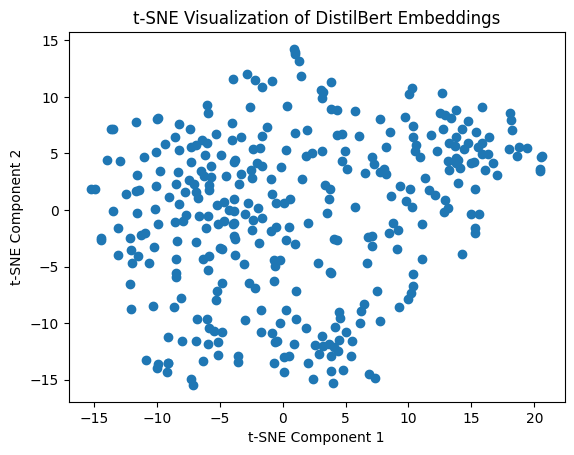

In [54]:

def visualize_embeddings_tsne(place_embeddings):
    # Convert the Series of lists to a 2D numpy array
    place_embeddings = np.vstack(place_embeddings)
    
    # Perform t-SNE to reduce to 2D
    tsne = TSNE(n_components=2, random_state=0)
    reduced_embeddings = tsne.fit_transform(place_embeddings)
    
    # Plot the 2D projections of the embeddings
    plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1])
    plt.title("t-SNE Visualization of DistilBert Embeddings")
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.show()

# Example usage with your attraction embeddings
visualize_embeddings_tsne(attraction_df['Embeddings'])
